<a href="https://colab.research.google.com/github/nusratcodes/ELA-AI-Generated-Image-Detection/blob/main/AI_generated_image_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Error Level Analysis (ELA) with Custom CNN for AI-Generated Image Detection

**Author:** Nusrat Hossain
**Date:** 2026

## Overview

This notebook implements Error Level Analysis (ELA) as a preprocessing step combined with a custom Convolutional Neural Network (CNN) to classify real and AI-generated images. The model is trained on the CIFAKE dataset (2,000 real + 2,000 fake images) and evaluated using accuracy, precision, recall, F1, and AUC.

## Pipeline

1. **ELA Extraction** — Re-compress image at JPEG-95, compute pixel-wise difference, normalize.
2. **Custom CNN** — 4 convolutional blocks with BatchNorm and MaxPooling.
3. **Training** — AdamW optimizer, BCE loss, 10 epochs, batch size 32.
4. **Evaluation** — Accuracy, AUC, Confusion Matrix.

## Dataset

**CIFAKE** — 2,000 real + 2,000 fake (train), 500 + 500 (validation), resized to 128×128.

## Results

| Metric | Value |
|---|---|
| Accuracy | 0.7670 |
| Precision | 0.7613 |
| Recall | 0.7780 |
| F1 | 0.7695 |
| AUC | 0.8519 |

**Observation:** The model achieves 76.7% accuracy and 0.85 AUC, indicating that ELA retains meaningful forensic signal even at 32×32 resolution. Performance is limited by the low image size, where JPEG compression artifacts are minimal; higher-resolution inputs are expected to yield better results.

## Environment

Google Colab (T4 GPU) • PyTorch • OpenCV • scikit-learn

In [ ]:
!nvidia-smi

Wed Sep 23 09:43:26 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   49C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
from google.colab import files
uploaded = files.upload()
print("Uploaded files:", list(uploaded.keys()))

Saving kaggle.json to kaggle.json
Uploaded files: ['kaggle.json']


In [ ]:
import os, shutil
os.makedirs('/root/.kaggle', exist_ok=True)
shutil.move('kaggle.json', '/root/.kaggle/kaggle.json')
os.chmod('/root/.kaggle/kaggle.json', 600)
print(" Kaggle ready")

 Kaggle ready


In [ ]:
!kaggle datasets download -d birdy654/cifake-real-and-ai-generated-synthetic-images

Dataset URL: https://www.kaggle.com/datasets/birdy654/cifake-real-and-ai-generated-synthetic-images
License(s): other
100% 105M/105M [00:00<00:00, 139MB/s] 



In [ ]:
!unzip -q cifake-real-and-ai-generated-synthetic-images.zip -d /content/cifake_data

In [ ]:
import os
print("Folders:", os.listdir('/content/cifake_data'))
print("Train:", os.listdir('/content/cifake_data/train'))
print("Test :", os.listdir('/content/cifake_data/test'))

Folders: ['test', 'train']
Train: ['REAL', 'FAKE']
Test : ['REAL', 'FAKE']


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import cv2
import os, random
from PIL import Image
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import datasets, transforms
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score)
from tqdm import tqdm
import matplotlib.pyplot as plt

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print("Device:", device)

Device: cuda


In [ ]:
def make_ela(img_pil, quality=95):
    """PIL Image → ELA map"""
    img = np.array(img_pil.convert('RGB'))
    img_bgr = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
    _, enc = cv2.imencode('.jpg', img_bgr, [cv2.IMWRITE_JPEG_QUALITY, quality])
    dec = cv2.imdecode(enc, 1)
    diff = cv2.absdiff(img_bgr, dec)
    diff = cv2.normalize(diff, None, 0, 255, cv2.NORM_MINMAX)
    return Image.fromarray(cv2.cvtColor(diff, cv2.COLOR_BGR2RGB))


class ELADataset(Dataset):
    def __init__(self, base, transform=None):
        self.base = base
        self.transform = transform
    def __len__(self):
        return len(self.base)
    def __getitem__(self, i):
        img, label = self.base[i]
        ela = make_ela(img)
        if self.transform:
            ela = self.transform(ela)
        return ela, label

print("ELA functions ready")

ELA functions ready


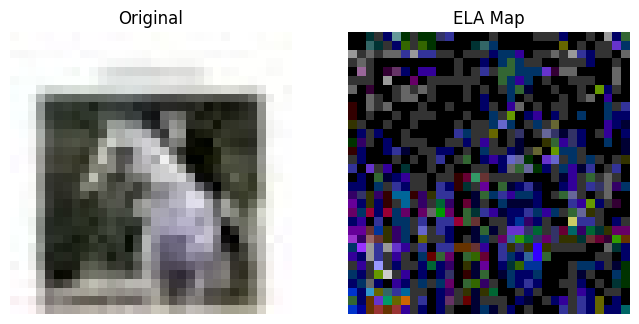

In [ ]:
real_dir = '/content/cifake_data/train/REAL'
first_file = os.listdir(real_dir)[0]
img_path = os.path.join(real_dir, first_file)

img = Image.open(img_path).convert('RGB')
ela = make_ela(img)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(img); axes[0].set_title('Original')
axes[1].imshow(ela); axes[1].set_title('ELA Map')
for ax in axes: ax.axis('off')
plt.show()

In [ ]:
raw_train = datasets.ImageFolder('/content/cifake_data/train', transform=None)
raw_test  = datasets.ImageFolder('/content/cifake_data/test',  transform=None)

# Balanced split
fake_train = [i for i, (_, y) in enumerate(raw_train) if y == 0]
real_train = [i for i, (_, y) in enumerate(raw_train) if y == 1]
fake_test  = [i for i, (_, y) in enumerate(raw_test)  if y == 0]
real_test  = [i for i, (_, y) in enumerate(raw_test)  if y == 1]

random.seed(42)
train_idx = random.sample(fake_train, 2000) + random.sample(real_train, 2000)
val_idx   = random.sample(fake_test,  500)  + random.sample(real_test,  500)
random.shuffle(train_idx); random.shuffle(val_idx)

train_sub = Subset(raw_train, train_idx)
val_sub   = Subset(raw_test,  val_idx)

# Transform
transform_ela_train = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
])
transform_ela_val = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
])

# Datasets
train_ela = ELADataset(train_sub, transform_ela_train)
val_ela   = ELADataset(val_sub,   transform_ela_val)

# DataLoaders
train_loader_ela = DataLoader(train_ela, batch_size=32, shuffle=True,  num_workers=2)
val_loader_ela   = DataLoader(val_ela,   batch_size=32, shuffle=False, num_workers=2)

print(f"Train: {len(train_ela)}, Val: {len(val_ela)}")

Train: 4000, Val: 1000


In [ ]:
class ELA_CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            # Block 2
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            # Block 3
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
            # Block 4
            nn.Conv2d(128, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d(1),
        )
        self.fc = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(128, 1)
        )
    def forward(self, x):
        return self.fc(self.net(x).flatten(1))

ela_model = ELA_CNN().to(device)
params = sum(p.numel() for p in ela_model.parameters())
print(f"ELA CNN params: {params/1e3:.1f}K")

ELA CNN params: 241.7K


In [ ]:
def train_ela(model, train_loader, val_loader, epochs=10, lr=3e-4):
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.BCEWithLogitsLoss()

    best_auc = 0
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for x, y in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
            x, y = x.to(device), y.float().to(device).unsqueeze(1)
            optimizer.zero_grad()
            pred = model(x)
            loss = criterion(pred, y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        scheduler.step()

        # Validation
        model.eval()
        preds, labels = [], []
        with torch.no_grad():
            for x, y in val_loader:
                x = x.to(device)
                p = torch.sigmoid(model(x)).cpu().numpy().flatten()
                preds.extend(p)
                labels.extend(y.numpy())
        acc = accuracy_score(labels, (np.array(preds) > 0.5).astype(int))
        try:
            auc = roc_auc_score(labels, preds)
        except ValueError:
            auc = float('nan')
        print(f"Epoch {epoch+1}: Loss={total_loss/len(train_loader):.4f}, Acc={acc:.4f}, AUC={auc:.4f}")

        if auc > best_auc:
            best_auc = auc
            torch.save(model.state_dict(), '/content/best_ela.pth')

    print(f"\n Best AUC: {best_auc:.4f}")
    return model

print(" Training function ready")

 Training function ready


In [ ]:
ela_model = train_ela(
    ela_model,
    train_loader_ela,
    val_loader_ela,
    epochs=10,
    lr=3e-4
)

Epoch 1: 100%|██████████| 125/125 [00:06<00:00, 20.26it/s]


Epoch 1: Loss=0.5819, Acc=0.6850, AUC=0.7904


Epoch 2: 100%|██████████| 125/125 [00:04<00:00, 29.55it/s]


Epoch 2: Loss=0.5449, Acc=0.5820, AUC=0.7999


Epoch 3: 100%|██████████| 125/125 [00:04<00:00, 28.13it/s]


...

Epoch 8: Loss=0.4924, Acc=0.7830, AUC=0.8509


Epoch 9: 100%|██████████| 125/125 [00:04<00:00, 29.17it/s]


Epoch 9: Loss=0.4897, Acc=0.7760, AUC=0.8506


Epoch 10: 100%|██████████| 125/125 [00:04<00:00, 26.61it/s]


Epoch 10: Loss=0.4844, Acc=0.7670, AUC=0.8519

 Best AUC: 0.8519


In [ ]:
ela_model.load_state_dict(torch.load('/content/best_ela.pth'))
ela_model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for x, y in val_loader_ela:
        x = x.to(device)
        p = torch.sigmoid(ela_model(x)).cpu().numpy().flatten()
        all_preds.extend(p)
        all_labels.extend(y.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
binary = (all_preds > 0.5).astype(int)

print("=" * 40)
print(f"Accuracy : {accuracy_score(all_labels, binary):.4f}")
print(f"Precision: {precision_score(all_labels, binary):.4f}")
print(f"Recall   : {recall_score(all_labels, binary):.4f}")
print(f"F1       : {f1_score(all_labels, binary):.4f}")
print(f"AUC      : {roc_auc_score(all_labels, all_preds):.4f}")
print("=" * 40)

Accuracy : 0.7670
Precision: 0.7613
Recall   : 0.7780
F1       : 0.7695
AUC      : 0.8519


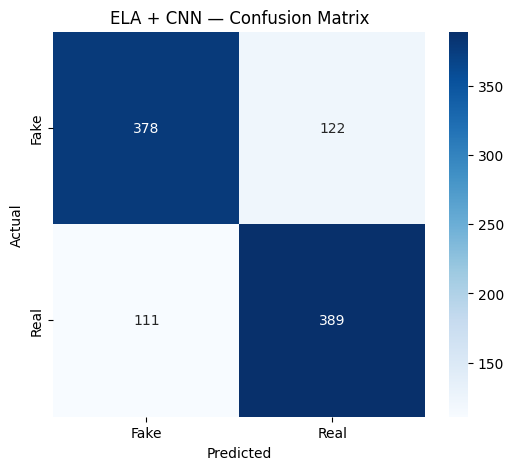

              precision    recall  f1-score   support

        Fake       0.77      0.76      0.76       500
        Real       0.76      0.78      0.77       500

    accuracy                           0.77      1000
   macro avg       0.77      0.77      0.77      1000
weighted avg       0.77      0.77      0.77      1000



In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(all_labels, binary)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'])
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.title('ELA + CNN — Confusion Matrix')
plt.show()

print(classification_report(all_labels, binary, target_names=['Fake', 'Real']))